In [ ]:
# from google.colab import drive
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Mount Google Drive
# drive.mount('/content/drive')

# BASE_PATH = '/content/drive/MyDrive/Computer Vision Dataset'
BASE_PATH = r"D:\Spring 2026\Adv Computer Vision\Group Project\dataset"
REAL_DIR = os.path.join(BASE_PATH, 'real_dataset')
AI_DIR = os.path.join(BASE_PATH, 'Ai_generated_dataset')
CATEGORIES = ['animals', 'city', 'food', 'nature', 'people']

Total Real Images: 745
Total AI Images: 250


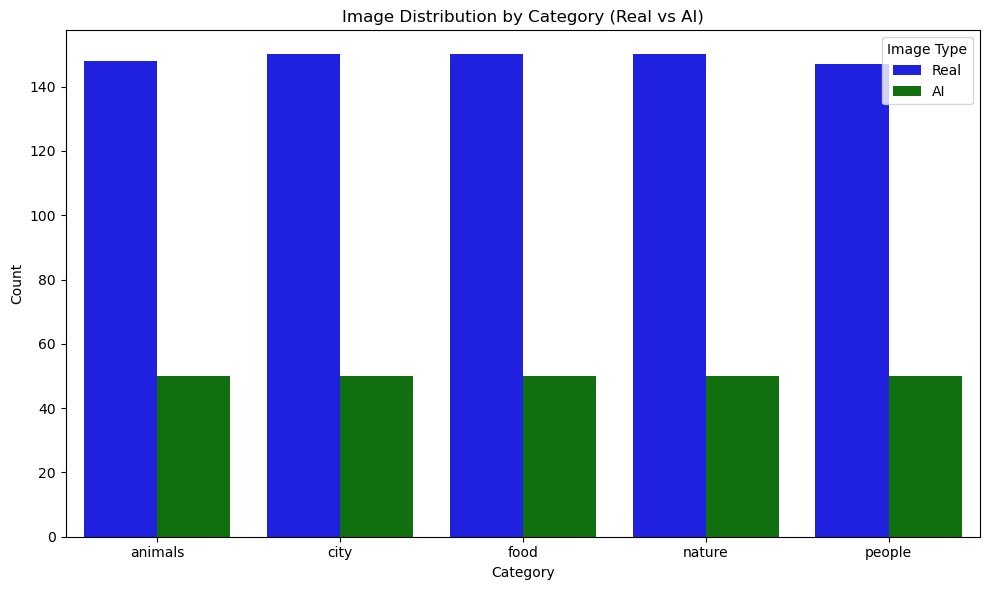

In [ ]:
import pandas as pd
def get_distribution(base_dir):
    dist = {}
    for cat in CATEGORIES:
        cat_path = os.path.join(base_dir, cat)
        if os.path.exists(cat_path):
            # Exclude hidden files or non-image files if any exist
            valid_images = [f for f in os.listdir(cat_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            dist[cat] = len(valid_images)
    return dist

real_dist = get_distribution(REAL_DIR)
ai_dist = get_distribution(AI_DIR)

print(f"Total Real Images: {sum(real_dist.values())}")
print(f"Total AI Images: {sum(ai_dist.values())}")

data = {
    'Category': list(real_dist.keys()) + list(ai_dist.keys()),
    'Count': list(real_dist.values()) + list(ai_dist.values()),
    'Type': ['Real'] * len(real_dist) + ['AI'] * len(ai_dist)
}
df_dist = pd.DataFrame(data)

# Plotting the combined distribution
plt.figure(figsize=(10, 6))
sns.barplot(x='Category', y='Count', hue='Type', data=df_dist, palette={'Real': 'blue', 'AI': 'green'})
plt.title("Image Distribution by Category (Real vs AI)")
plt.ylabel("Count")
plt.xlabel("Category")
plt.legend(title='Image Type')
plt.tight_layout()
plt.show()

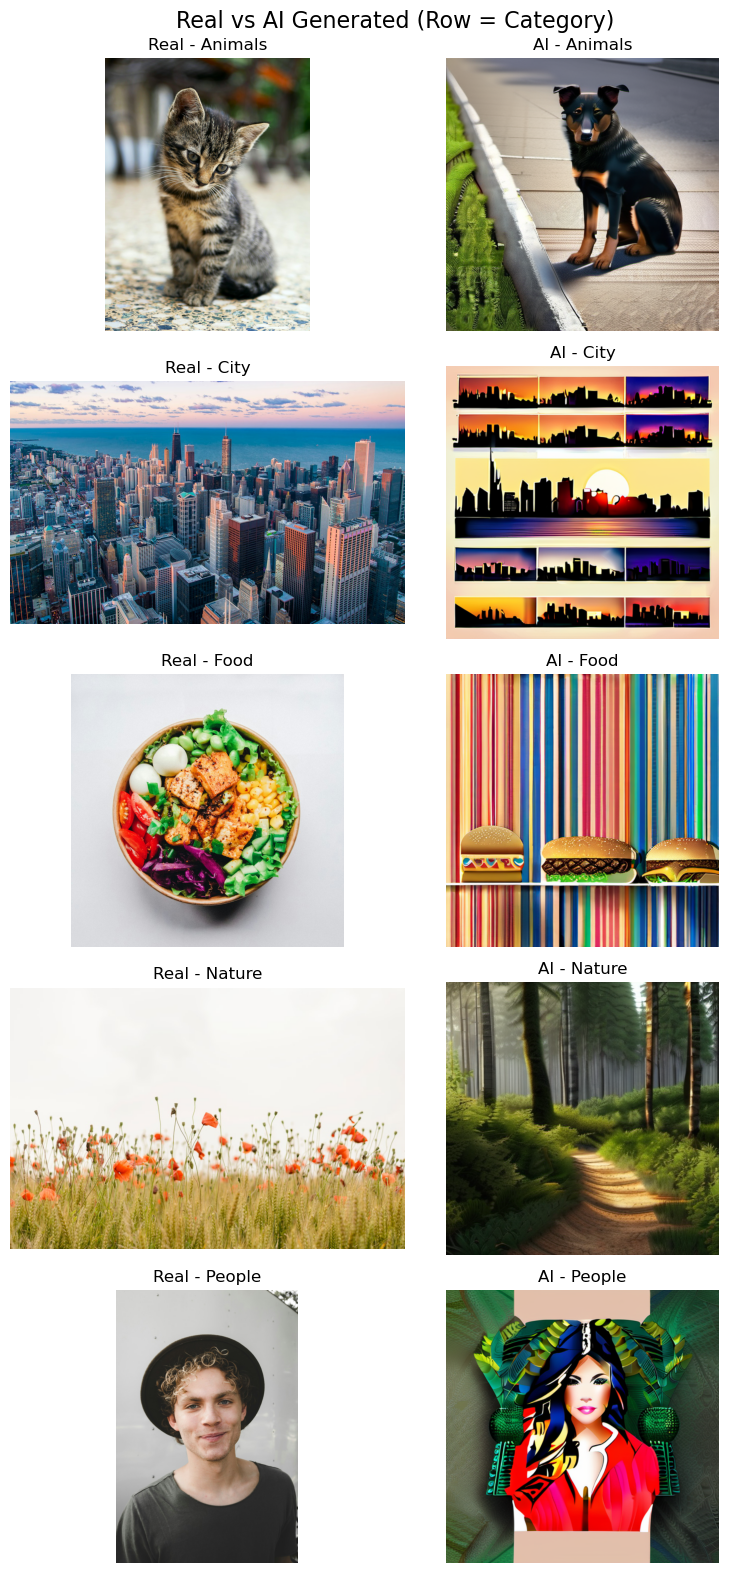

In [5]:
def plot_comparisons():
    fig, axes = plt.subplots(len(CATEGORIES), 2, figsize=(8, 16))
    fig.suptitle('Real vs AI Generated (Row = Category)', fontsize=16)

    for i, cat in enumerate(CATEGORIES):
        real_img_path = os.path.join(REAL_DIR, cat, os.listdir(os.path.join(REAL_DIR, cat))[0])
        ai_img_path = os.path.join(AI_DIR, cat, os.listdir(os.path.join(AI_DIR, cat))[0])

        # Load images
        real_img = Image.open(real_img_path)
        ai_img = Image.open(ai_img_path)

        # Plot Real
        axes[i, 0].imshow(real_img)
        axes[i, 0].set_title(f"Real - {cat.capitalize()}")
        axes[i, 0].axis('off')

        # Plot AI
        axes[i, 1].imshow(ai_img)
        axes[i, 1].set_title(f"AI - {cat.capitalize()}")
        axes[i, 1].axis('off')

    plt.tight_layout()
    fig.subplots_adjust(top=0.95)
    plt.show()

plot_comparisons()

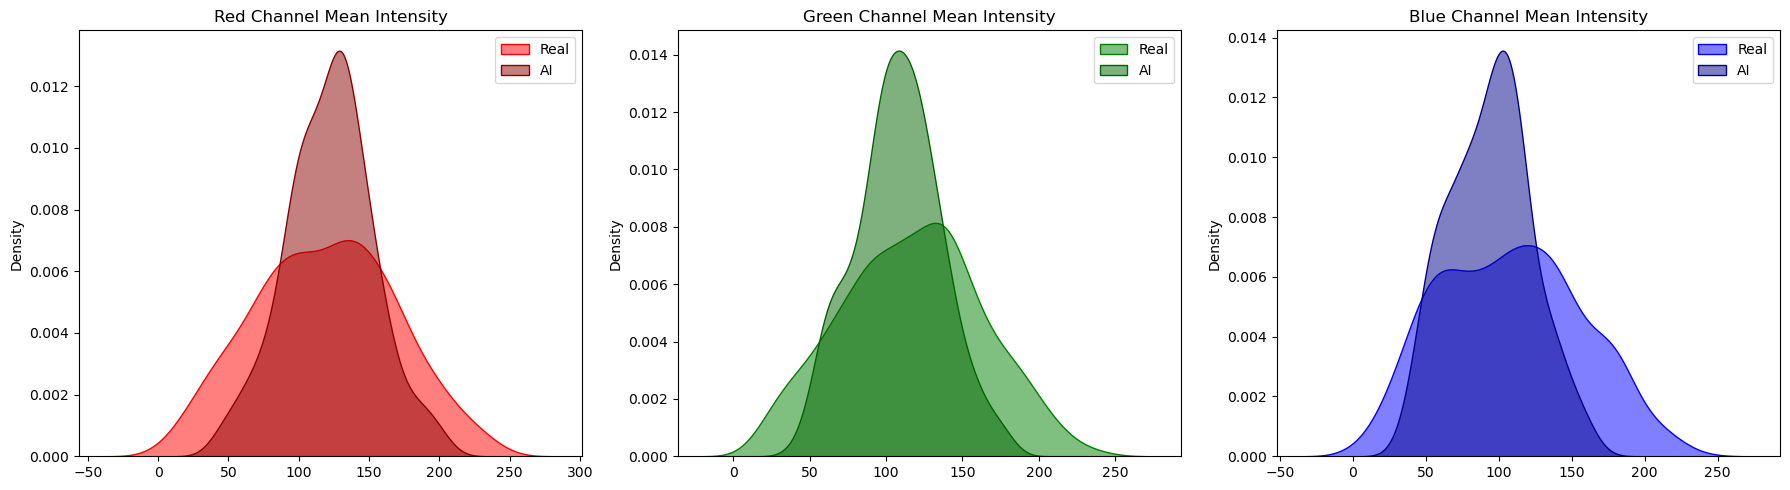

In [6]:
def analyze_image_properties(base_dir, label):
    widths, heights = [], []
    mean_r, mean_g, mean_b = [], [], []

    for cat in CATEGORIES:
        cat_path = os.path.join(base_dir, cat)
        if not os.path.exists(cat_path): continue

        for img_name in os.listdir(cat_path):
            img_path = os.path.join(cat_path, img_name)
            img = cv2.imread(img_path)

            if img is not None:
                # Get dimensions
                h, w, _ = img.shape
                widths.append(w)
                heights.append(h)

                # Convert to RGB and get channel means
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                mean_r.append(np.mean(img_rgb[:,:,0]))
                mean_g.append(np.mean(img_rgb[:,:,1]))
                mean_b.append(np.mean(img_rgb[:,:,2]))

    return widths, heights, mean_r, mean_g, mean_b

# Extract properties
r_w, r_h, r_mr, r_mg, r_mb = analyze_image_properties(REAL_DIR, "Real")
ai_w, ai_h, ai_mr, ai_mg, ai_mb = analyze_image_properties(AI_DIR, "AI")

# Plot RGB Histograms
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.kdeplot(r_mr, color='red', fill=True, label='Real', ax=axes[0], alpha=0.5)
sns.kdeplot(ai_mr, color='darkred', fill=True, label='AI', ax=axes[0], alpha=0.5)
axes[0].set_title('Red Channel Mean Intensity')
axes[0].legend()

sns.kdeplot(r_mg, color='green', fill=True, label='Real', ax=axes[1], alpha=0.5)
sns.kdeplot(ai_mg, color='darkgreen', fill=True, label='AI', ax=axes[1], alpha=0.5)
axes[1].set_title('Green Channel Mean Intensity')
axes[1].legend()

sns.kdeplot(r_mb, color='blue', fill=True, label='Real', ax=axes[2], alpha=0.5)
sns.kdeplot(ai_mb, color='darkblue', fill=True, label='AI', ax=axes[2], alpha=0.5)
axes[2].set_title('Blue Channel Mean Intensity')
axes[2].legend()

plt.tight_layout()
plt.show()

### Image Dimension Analysis

C:\Users\alekh\AppData\Local\Temp\ipykernel_42492\3273043657.py:3: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(r_w, color='purple', fill=True, label='Real', ax=axes[0], alpha=0.5)


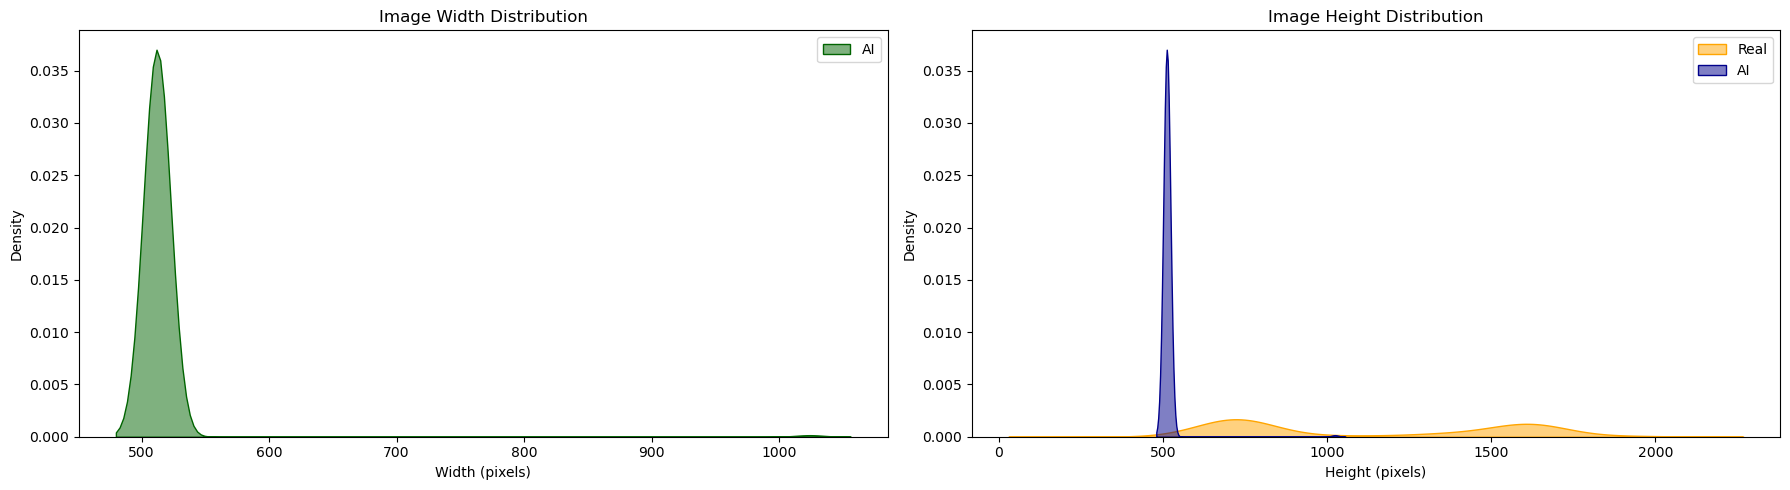

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.kdeplot(r_w, color='purple', fill=True, label='Real', ax=axes[0], alpha=0.5)
sns.kdeplot(ai_w, color='darkgreen', fill=True, label='AI', ax=axes[0], alpha=0.5)
axes[0].set_title('Image Width Distribution')
axes[0].set_xlabel('Width (pixels)')
axes[0].legend()

sns.kdeplot(r_h, color='orange', fill=True, label='Real', ax=axes[1], alpha=0.5)
sns.kdeplot(ai_h, color='darkblue', fill=True, label='AI', ax=axes[1], alpha=0.5)
axes[1].set_title('Image Height Distribution')
axes[1].set_xlabel('Height (pixels)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming variables from previous setup:
# BASE_PATH, REAL_DIR, AI_DIR, CATEGORIES

def extract_advanced_features(base_dir, label):
    data = []

    for cat in CATEGORIES:
        cat_path = os.path.join(base_dir, cat)
        if not os.path.exists(cat_path):
            continue

        for img_name in os.listdir(cat_path):
            img_path = os.path.join(cat_path, img_name)
            img = cv2.imread(img_path)

            if img is None:
                continue

            # 1. Dimensions & Aspect Ratio
            h, w, _ = img.shape
            aspect_ratio = w / h

            # Convert color spaces for analysis
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

            # 2. Brightness (Mean pixel intensity) & Contrast (Std Dev of intensity)
            brightness = np.mean(gray)
            contrast = np.std(gray)

            # 3. Sharpness / Focus (Variance of the Laplacian)
            # AI images sometimes lack natural lens blur or high-frequency noise
            sharpness = cv2.Laplacian(gray, cv2.CV_64F).var()

            # 4. Color Saturation
            # AI generators sometimes produce hyper-saturated "perfect" lighting
            mean_saturation = np.mean(hsv[:, :, 1])

            data.append({
                'Label': label,
                'Category': cat,
                'Width': w,
                'Height': h,
                'Aspect_Ratio': aspect_ratio,
                'Brightness': brightness,
                'Contrast': contrast,
                'Sharpness': sharpness,
                'Saturation': mean_saturation
            })

    return pd.DataFrame(data)

# Extract features and combine them into one DataFrame
print("Extracting features from Real Images...")
df_real = extract_advanced_features(REAL_DIR, 'Real')

print("Extracting features from AI Images...")
df_ai = extract_advanced_features(AI_DIR, 'AI')

# Combine DataFrames
df = pd.concat([df_real, df_ai], ignore_index=True)
print("Feature extraction complete! Total images analyzed:", len(df))

Extracting features from Real Images...
Extracting features from AI Images...
Feature extraction complete! Total images analyzed: 995


C:\Users\alekh\AppData\Local\Temp\ipykernel_42492\121029060.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x='Aspect_Ratio', hue='Label', fill=True, ax=axes[1], palette=['#1f77b4', '#ff7f0e'])


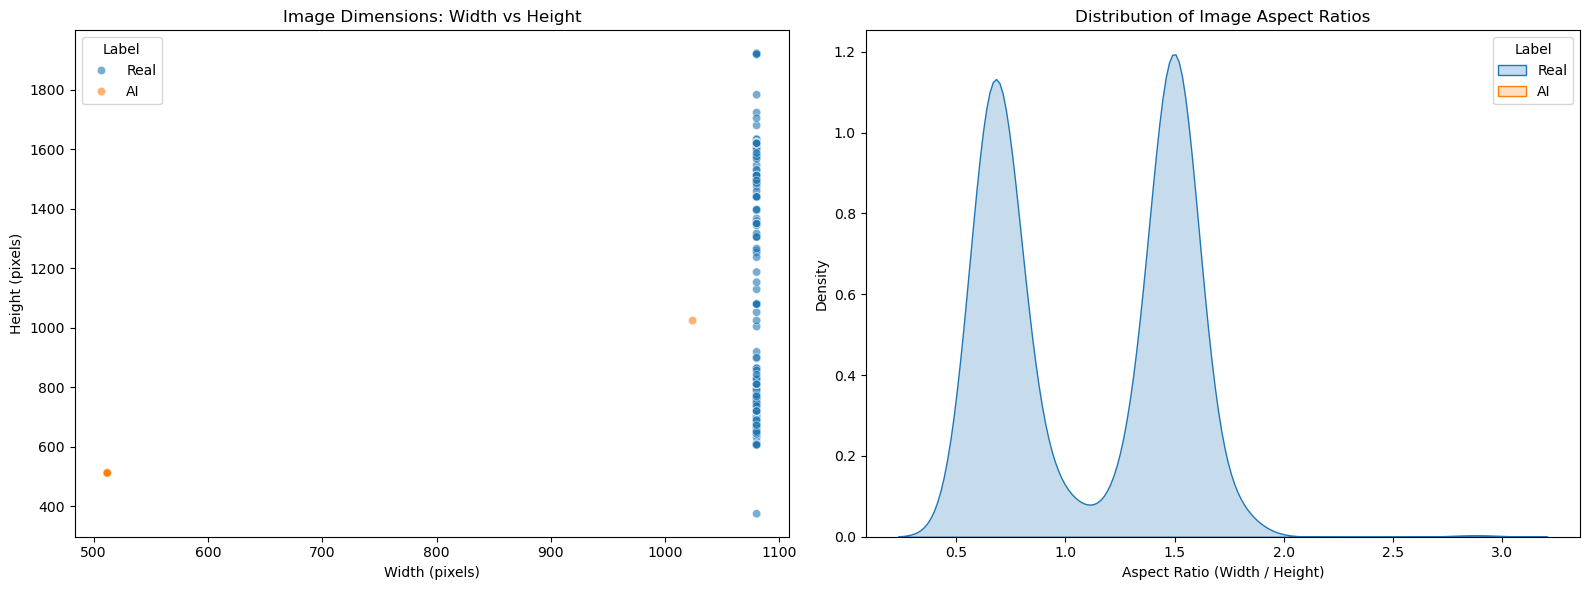

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter Plot of Width vs Height
sns.scatterplot(data=df, x='Width', y='Height', hue='Label', alpha=0.6, ax=axes[0], palette=['#1f77b4', '#ff7f0e'])
axes[0].set_title('Image Dimensions: Width vs Height')
axes[0].set_xlabel('Width (pixels)')
axes[0].set_ylabel('Height (pixels)')

# Density Plot of Aspect Ratios
sns.kdeplot(data=df, x='Aspect_Ratio', hue='Label', fill=True, ax=axes[1], palette=['#1f77b4', '#ff7f0e'])
axes[1].set_title('Distribution of Image Aspect Ratios')
axes[1].set_xlabel('Aspect Ratio (Width / Height)')

plt.tight_layout()
plt.show()

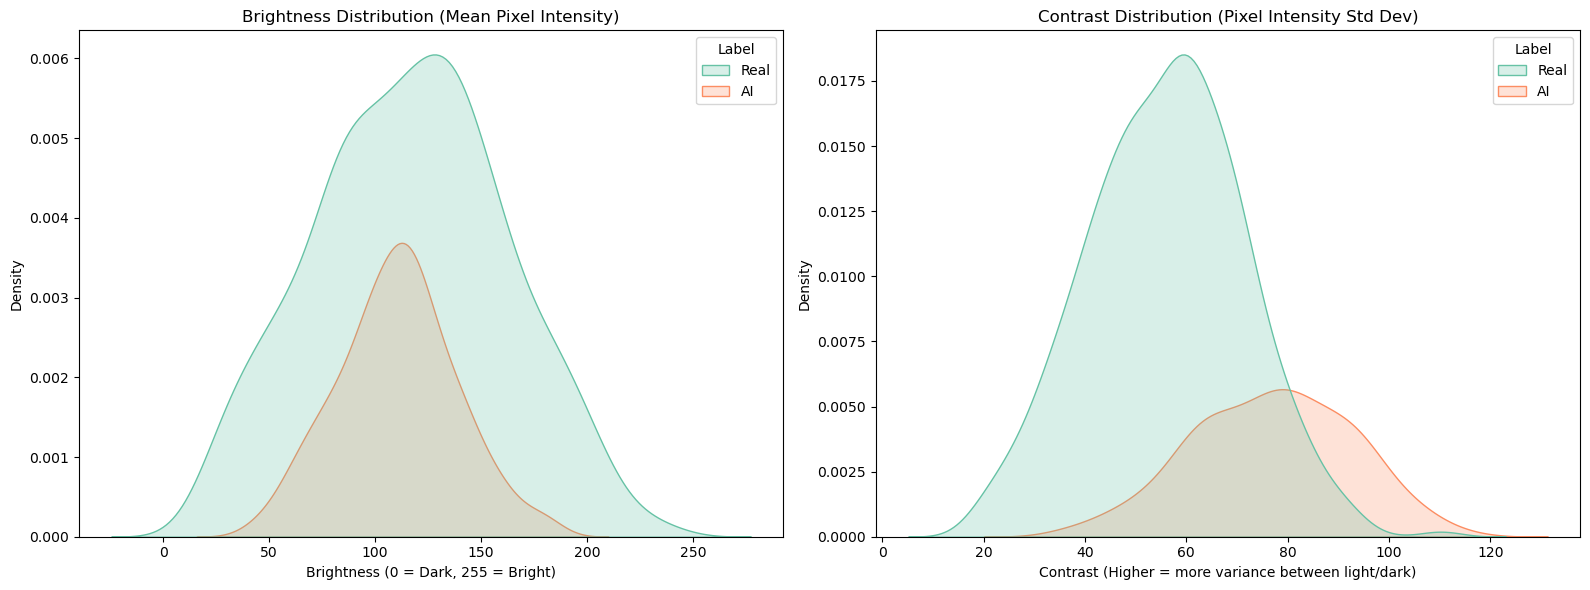

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Brightness
sns.kdeplot(data=df, x='Brightness', hue='Label', fill=True, ax=axes[0], palette='Set2')
axes[0].set_title('Brightness Distribution (Mean Pixel Intensity)')
axes[0].set_xlabel('Brightness (0 = Dark, 255 = Bright)')

# Contrast
sns.kdeplot(data=df, x='Contrast', hue='Label', fill=True, ax=axes[1], palette='Set2')
axes[1].set_title('Contrast Distribution (Pixel Intensity Std Dev)')
axes[1].set_xlabel('Contrast (Higher = more variance between light/dark)')

plt.tight_layout()
plt.show()

C:\Users\alekh\AppData\Local\Temp\ipykernel_42492\2657834739.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='Log_Sharpness', ax=axes[0], palette='Pastel1')
C:\Users\alekh\AppData\Local\Temp\ipykernel_42492\2657834739.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='Saturation', ax=axes[1], palette='Pastel1')


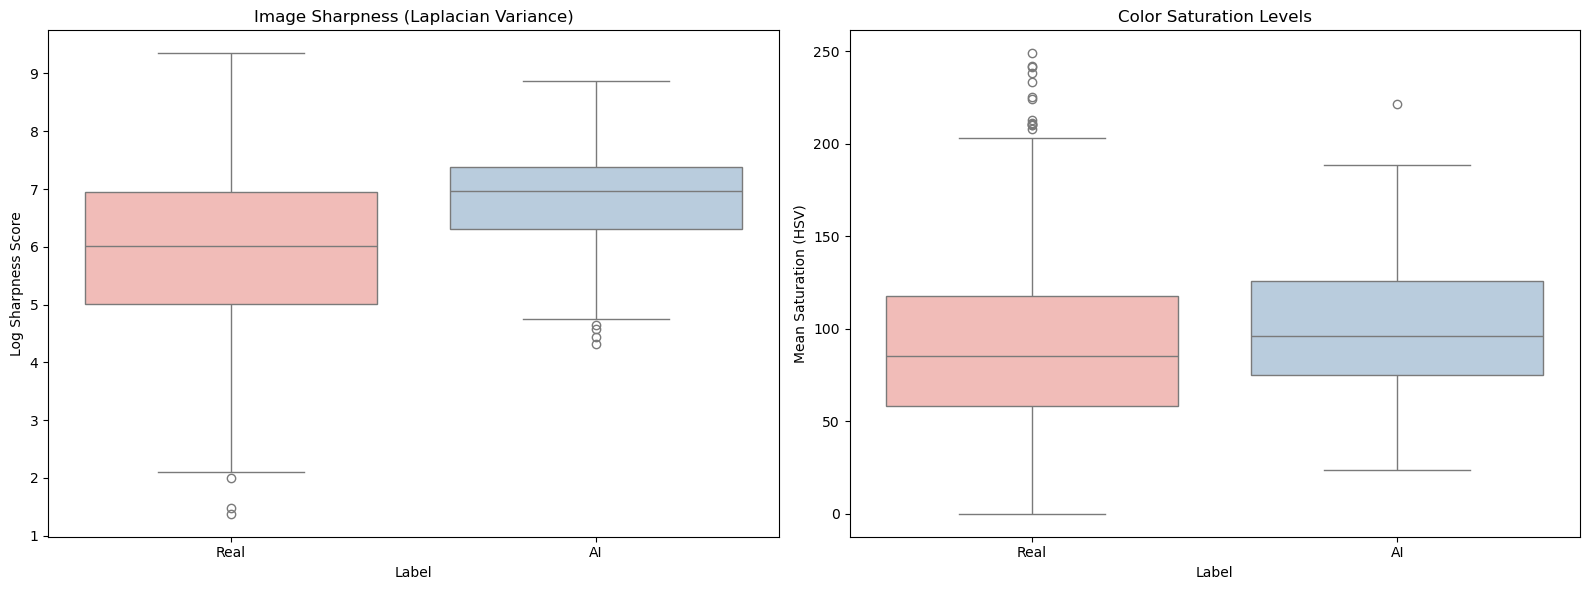

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sharpness (Log scale is often better as Laplacian variance can range wildly)
df['Log_Sharpness'] = np.log1p(df['Sharpness'])
sns.boxplot(data=df, x='Label', y='Log_Sharpness', ax=axes[0], palette='Pastel1')
axes[0].set_title('Image Sharpness (Laplacian Variance)')
axes[0].set_ylabel('Log Sharpness Score')

# Saturation
sns.boxplot(data=df, x='Label', y='Saturation', ax=axes[1], palette='Pastel1')
axes[1].set_title('Color Saturation Levels')
axes[1].set_ylabel('Mean Saturation (HSV)')

plt.tight_layout()
plt.show()